## Forced Isotropic Turbulence

First, let's load the initial conditions. The data is from the Johns Hopkins Turbulence Database (JHTDB) and contains a 1024^3 isotropic turbulence simulation. We use the `hf_hub_download` function to download the data directly from the Hugging Face Hub.

In [2]:
from huggingface_hub import hf_hub_download

t= 420
DATA_FILE = hf_hub_download(
    repo_id="thuerey-group/jhtdb-isotropic-turbulence-1024",
    filename=f"coarse_t{t}.hdf5",
    repo_type="dataset",
)

We need the h5py library to read the data from the HDF5 file. It is not part of the required dependencies for the P3D models, so we install it separately here.

In [4]:
!pip install h5py --quiet
import h5py

Load the data from the HDF5 file. Note that we provide timestep 420; other timesteps can be downloaded directly from JHTDB; see `data/download_jhtdb.py` for details.

In [5]:
crop_size = 256
T_STEP = 10

import numpy as np

with h5py.File(DATA_FILE, 'r') as f:

    expected_key = str((t - 1) // T_STEP)
    keys = list(f['sims/sim0'].keys())
    key = expected_key if expected_key in keys else keys[0]

    frame_0 = f[f'sims/sim0/{key}'][:crop_size, :crop_size, :crop_size]
    input_0 = np.transpose(frame_0[None], (0, 4, 1, 2, 3))

Check the tensor shape

In [6]:
input_0.shape

(1, 4, 256, 256, 256)

Load the P3D-S model with pretrained weights from huggingface.

In [8]:
from p3d_surrogate import P3D_S
from p3d_surrogate.utils import get_state_dict_from_hub

model = P3D_S(channel_size=4, channel_size_out=4)

filename = "P3D_S_iso_crop128.ckpt"
state_dict = get_state_dict_from_hub(filename)

model.load_state_dict(state_dict, strict=True)
model = model.cuda()
model = model.eval()

/home/holzschuh/anaconda3/envs/testp3d_v2/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/holzschuh/anaconda3/envs/testp3d_v2/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Now we can run the model autoregressively for a few timesteps and visualize the results.

In [9]:
import torch

class_labels   = torch.tensor([14],  device=model.device, dtype=torch.long) # internal label for isotropic turbulence
output_list = [input_0]
timesteps = 5

with torch.no_grad():

    for i in range (timesteps):
        out = model(torch.from_numpy(output_list[-1]).float().cuda(), class_labels=class_labels)
        output_list.append(out.sample.cpu().numpy())

Let's plot the results (a single slice of the velocity field in x-direction). <br> Note that for long rollouts, the model will start to become blurry due to the uncertainty from the boundary. <br> For stable long rollouts, we need the full 1024^3 data, which has periodic boundary conditions (there is a parameter to initialize the model as periodic for this case).

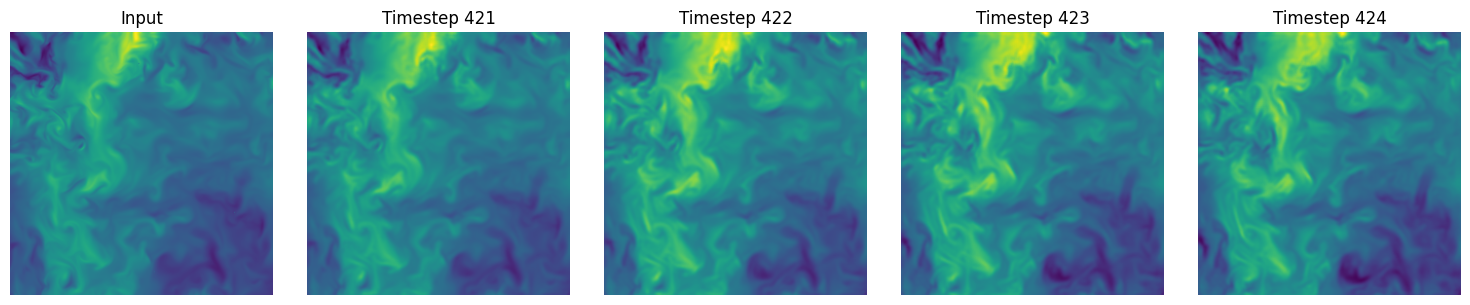

In [10]:
import math
from matplotlib import pyplot as plt

cols = 5
rows = math.ceil(timesteps / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(timesteps):
    axes[i].imshow(output_list[i][0, 0][128])
    if (i == 0):
        axes[i].set_title(f'Input')
    else:
        axes[i].set_title(f'Timestep {t+i}')
    axes[i].axis('off')

for ax in axes[timesteps:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()